# Use Case 3 — EPC Project TKG: Dataset Exploration

**Domain:** EPC project monitoring with causal chain analysis.

**Data sources (synthetic, PSPLIB-style):**
| File | Entities | Description |
|------|----------|-------------|
| `activities.csv` | 60 | Work packages, planned/actual dates, delays |
| `procurement.csv` | 18 | Purchase orders with delivery status |
| `documents.csv` | 30 | Engineering docs with approval workflow |
| `events.csv` | 25 | Change orders, NCRs, Inspections |
| `causal_ground_truth.json` | 5 chains | Known cause-effect relationships |

**TKG Schema:**
```
(Activity)-[:PRECEDED_BY]->(Activity)
(Activity)-[:LINKED_TO]->(PurchaseOrder)
(Activity)-[:REQUIRES_DOC]->(Document)
(Event)-[:IMPACTS]->(Activity)
(PurchaseOrder)-[:TRIGGERED]->(Event)
```

**Notebooks:**
- **01 (this):** Explore entities, delays, event types
- **02:** Build TKG + Neo4j import
- **03:** T-Logic causal chain validation against ground truth


## 0. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../../data/UseCase3')
print('Setup OK')


Setup OK


/home/obiaggi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load All Data Sources


In [2]:
df_act  = pd.read_csv(DATA_DIR / 'activities.csv', parse_dates=['planned_start','planned_finish','actual_start','actual_finish'])
df_proc = pd.read_csv(DATA_DIR / 'procurement.csv', parse_dates=['planned_order_dt','planned_deliv_dt','actual_deliv_dt'])
df_docs = pd.read_csv(DATA_DIR / 'documents.csv', parse_dates=['issue_date','planned_appr_date','actual_appr_date'])
df_ev   = pd.read_csv(DATA_DIR / 'events.csv', parse_dates=['date'])
with open(DATA_DIR / 'causal_ground_truth.json') as f:
    gt = json.load(f)

print(f'Activities:   {len(df_act):>3} | Delayed: {df_act["delayed"].sum()}')
print(f'Procurement:  {len(df_proc):>3} | Late: {(df_proc["delay_days"]>0).sum()}')
print(f'Documents:    {len(df_docs):>3} | Late approval: {(df_docs["late_days"]>0).sum()}')
print(f'Events:       {len(df_ev):>3}')
print(f'Causal chains: {len(gt["causal_chains"])}')


Activities:    60 | Delayed: 8
Procurement:   18 | Late: 3
Documents:     30 | Late approval: 2
Events:        25
Causal chains: 5


## 2. Activity Timeline


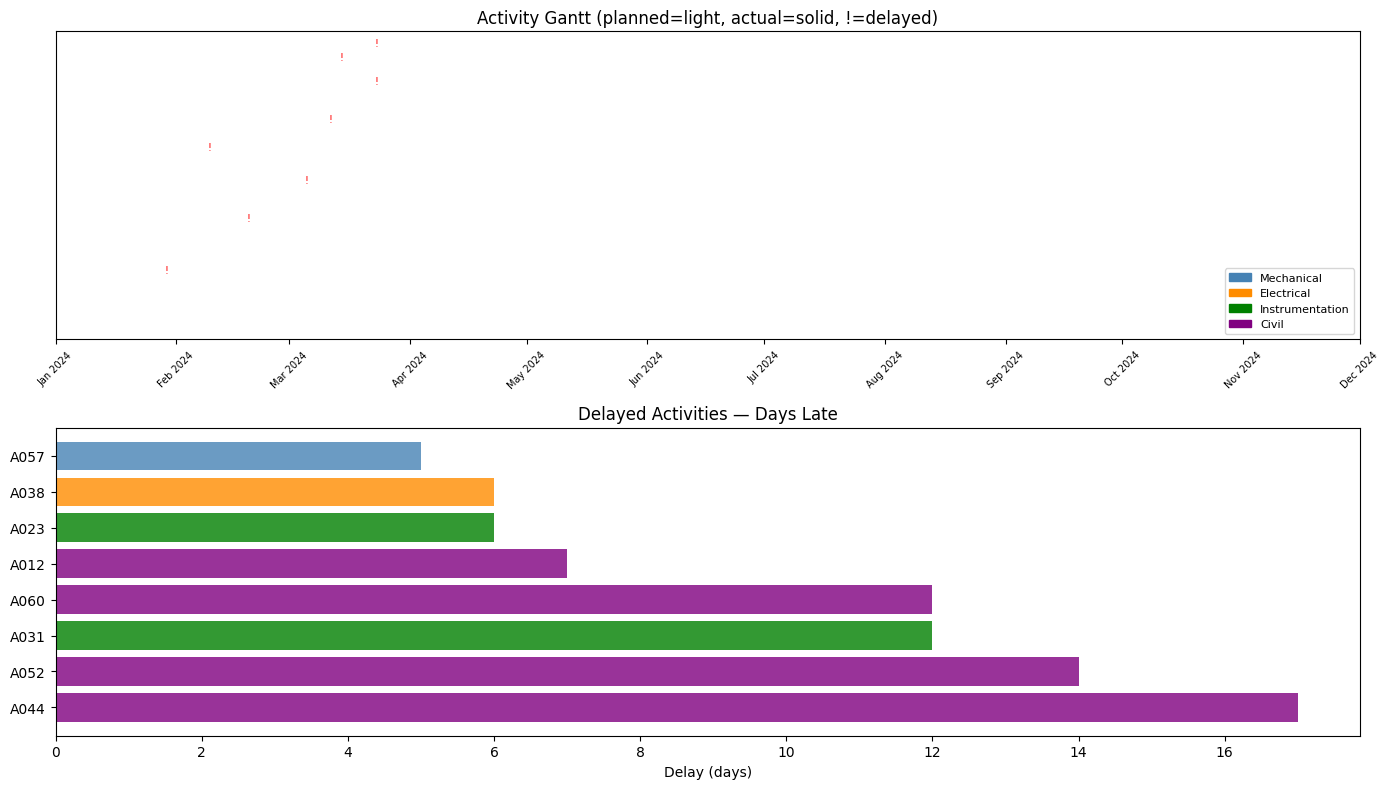

Delayed activities: 8 / 60 (13%)


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gantt chart
ax = axes[0]
disc_colors = {'Mechanical': 'steelblue', 'Electrical': 'darkorange',
               'Instrumentation': 'green', 'Civil': 'purple'}
delayed_acts = df_act[df_act['delayed'] == True]
on_time_acts = df_act[df_act['delayed'] == False]

for i, (_, row) in enumerate(df_act.iterrows()):
    color = disc_colors.get(row['discipline'], 'gray')
    alpha = 1.0 if row['delayed'] else 0.5
    # planned bar (light)
    ps = row['planned_start']; pe = row['planned_finish']
    ax.barh(i, (pe-ps).days, left=ps.timestamp(), height=0.4,
            color=color, alpha=0.3)
    # actual bar (solid, if available)
    if pd.notna(row['actual_start']) and pd.notna(row['actual_finish']):
        as_ = row['actual_start']; ae = row['actual_finish']
        ax.barh(i, (ae-as_).days, left=as_.timestamp(), height=0.4,
                color=color, alpha=alpha)
    if row['delayed']:
        ax.annotate('!', xy=(row['actual_finish'].timestamp(), i),
                    fontsize=7, color='red', ha='left')

import pandas as pd
xticks = pd.date_range('2024-01-01', '2024-12-01', freq='MS')
ax.set_xticks([x.timestamp() for x in xticks])
ax.set_xticklabels([x.strftime('%b %Y') for x in xticks], rotation=45, fontsize=7)
ax.set_title('Activity Gantt (planned=light, actual=solid, !=delayed)')
ax.set_yticks([])
patches = [mpatches.Patch(color=c, label=d) for d, c in disc_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8)

# Delay distribution
ax2 = axes[1]
delay_acts = df_act[df_act['delayed']].copy()
delay_acts['delay_days'] = (delay_acts['actual_finish'] - delay_acts['planned_finish']).dt.days
delay_acts_sorted = delay_acts.sort_values('delay_days', ascending=False)
colors2 = [disc_colors.get(d, 'gray') for d in delay_acts_sorted['discipline']]
ax2.barh(delay_acts_sorted['activity_id'], delay_acts_sorted['delay_days'], color=colors2, alpha=0.8)
ax2.set_title('Delayed Activities — Days Late')
ax2.set_xlabel('Delay (days)')

plt.tight_layout()
plt.show()
print(f'Delayed activities: {len(delay_acts)} / {len(df_act)} ({len(delay_acts)/len(df_act)*100:.0f}%)')


## 3. Events & Procurement Overview


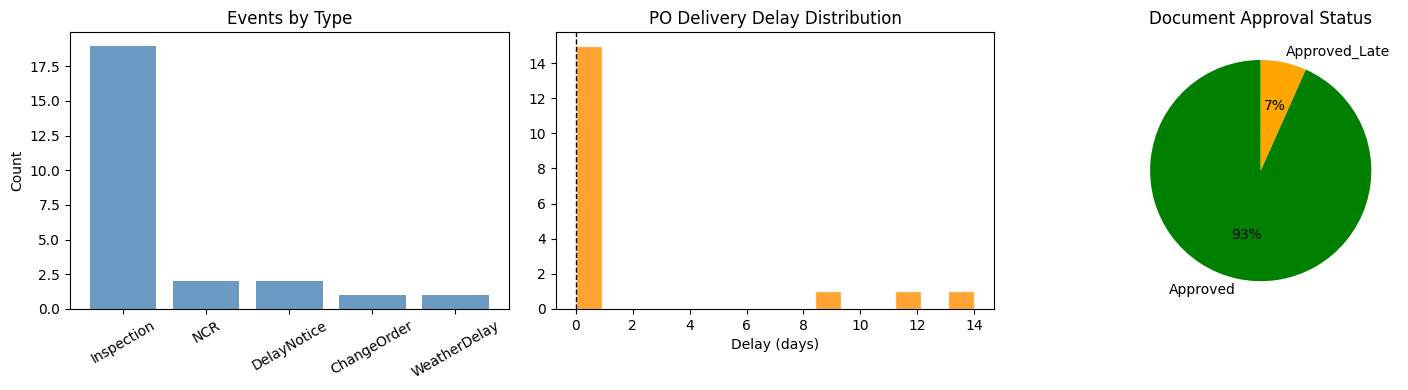

PO Delivery Summary:
                 count  mean  max
delivery_status                  
Late                 3  11.7   14
On Time             15   0.0    0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Event types
ev_counts = df_ev['event_type'].value_counts()
axes[0].bar(ev_counts.index, ev_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Events by Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Procurement delay distribution
axes[1].hist(df_proc['delay_days'].dropna(), bins=15, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('PO Delivery Delay Distribution')
axes[1].set_xlabel('Delay (days)')
axes[1].axvline(0, color='black', linestyle='--', lw=1)

# Document approval status
doc_status = df_docs['approval_status'].value_counts()
axes[2].pie(doc_status.values, labels=doc_status.index,
            colors=['green','orange','red','gray'][:len(doc_status)],
            autopct='%1.0f%%', startangle=90)
axes[2].set_title('Document Approval Status')

plt.tight_layout()
plt.show()

print('PO Delivery Summary:')
print(df_proc.groupby('delivery_status')['delay_days'].agg(['count','mean','max']).round(1).to_string())


## 4. Causal Ground Truth


In [5]:
print('Known Causal Chains:')
print('=' * 60)
for chain in gt['causal_chains']:
    print(f"\n{chain['chain_id']}: {chain['description']}")
    for step in chain['chain']:
        print(f"  [{step['timestamp']}] {step['entity']} --[{step['relation']}]-->")

print('\nEvaluation Questions:')
for i, q in enumerate(gt['evaluation_questions'], 1):
    print(f'  Q{i}: {q}')


Known Causal Chains:

CC-01: PO-003 late delivery caused A012 delay
  [2024-02-28] PO-003 --[deliveredLate]-->
  [2024-02-28] DN-001 --[triggeredDelayIn]-->
  [2024-03-12] A012 --[startedLate]-->

CC-02: NCR on PO-007 caused A023 delay
  [2024-03-20] PO-007 --[hadNCR]-->
  [2024-03-20] NCR-001 --[delayedActivity]-->
  [2024-03-29] A023 --[startedLate]-->

CC-03: DOC-012 late approval blocked A031
  [2024-04-08] DOC-012 --[approvedLate]-->
  [2024-04-08] A031 --[blockedByDocument]-->
  [2024-04-16] A031 --[startedLate]-->

CC-04: Change order CO-001 caused A038 delay, which cascaded to A044
  [2024-04-15] CO-001 --[issuedAt]-->
  [2024-04-15] A038 --[impactedByChange]-->
  [2024-04-25] A038 --[startedLate]-->
  [2024-05-05] A044 --[dependsOn_A038]-->

CC-05: NCR-002 and PO-014 delay cascaded to A057 and A060
  [2024-07-10] NCR-002 --[issuedAt]-->
  [2024-07-10] A057 --[delayedByNCR]-->
  [2024-07-22] A060 --[dependsOn_A057]-->
  [2024-07-22] A060 --[cascade_delay]-->

Evaluation Questio

## Summary

| Entity | Count | Key Metric |
|--------|-------|------------|
| Activities | 60 | 8 delayed (13%) |
| Purchase Orders | 18 | avg delay: varies by status |
| Documents | 30 | approval delays trigger activity blocks |
| Events | 25 | 19 Inspections, 2 NCRs, 1 ChangeOrder |
| Causal Chains | 5 | verifiable ground truth |

**Next:** `02_tkg_build.ipynb` — Build TKG + Neo4j import
